In [1]:
import os, sys, torch
import matplotlib.pyplot as plt

from pytorch3d.io import load_objs_as_meshes, IO
from pytorch3d.renderer import TexturesVertex
from pytorch3d.structures import Meshes

from pytorch3d.renderer import (
look_at_view_transform,
PerspectiveCameras,
FoVPerspectiveCameras,
PointLights,
Materials,
RasterizationSettings,
MeshRenderer,
MeshRasterizer,
TexturesUV
)

from pytorch3d.renderer.mesh.shader import HardPhongShader, HardFlatShader, HardGouraudShader

from pathlib import Path

sys.path.append(os.path.abspath(''))

## Загрузка модели

In [2]:
!curl https://raw.githubusercontent.com/PacktPublishing/3D-Deep-Learning-with-Python/refs/heads/main/chap2/data/cow_mesh/cow.mtl -o ./data/cow_mesh/cow.mtl

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0^C


In [2]:
DATA_DIR = Path("./data")
obj_filename = DATA_DIR / 'cow_mesh' / 'cow.obj'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [9]:
obj_filename = DATA_DIR / 'cow_mesh' / 'cow.obj'
obj_filename = "/home/student/work/3d_Generative/model/dataset/modelNet/ModelNet10/bathtub/test/bathtub_0107.off" # bed_0516.off 

mesh = IO().load_mesh(obj_filename, device=device)
if mesh.textures is None:
    print('No textures? :(')
else:
    print('ok!')

verts = mesh.verts_packed()
N = verts.shape[0]
center = verts.mean(0)
scale = max((verts - center).abs().max(0)[0])
mesh.offset_verts_(-(center.expand(N, 3)))
mesh.scale_verts_((1.0 / float(scale)))

No textures? :(


In [10]:
# mesh = load_objs_as_meshes([obj_filename], device=device)
from pytorch3d.renderer.mesh.textures import Textures
mesh = IO().load_mesh(obj_filename, device=device)

# maps = torch.ones(1, 128, 128, 3, dtype=torch.float32, device=device)
# textures = TexturesUV(maps=maps, faces_uvs=torch.ones_like(mesh.faces_packed())[None], verts_uvs=torch.ones_like(mesh.verts_packed())[None])


verts_colors = torch.full((1, mesh.verts_packed().shape[0], 3), 0.5, device=device)
textures = TexturesVertex(verts_features=verts_colors)


# texture_map = torch.ones((1, 1, 3), device=device)
# num_faces = mesh.faces_padded().shape[1]
# num_verts = mesh.verts_padded().shape[1]
# faces_uvs = torch.Tensor([0.5, 0.5, 0.5]).to(device).repeat(num_faces, 1)
# verts_uvs= torch.Tensor([0.5, 0.5]).to(device).repeat(1, num_verts, 1)
# textures = TexturesUV(maps=[texture_map], faces_uvs=[faces_uvs], verts_uvs=verts_uvs)

# mesh = Meshes(verts=[mesh.verts_padded()], faces=[mesh.faces_padded()], textures=textures)
mesh.textures = textures

## Создание виртуальной среды

In [11]:
# R, T = look_at_view_transform(100.0, -60, 30)
# cameras = PerspectiveCameras(device = device, R=R, T=T)

num_views = 40
azimuth_range = 180.

elev = torch.linspace(0, 0, num_views)  # keep constant
azim = torch.linspace(-azimuth_range, azimuth_range, num_views) + 180.0
R, T = look_at_view_transform(dist=100.0, elev=elev, azim=azim)
cameras = FoVPerspectiveCameras(device=device, R=R, T=T)
lights = PointLights(device=device, location=[[1.0, 0.0, 0.0]])

meshes = mesh.extend(num_views)

raster_settings = RasterizationSettings(
    image_size=512,
    blur_radius=0.0,
    faces_per_pixel=1
)

renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=cameras,
        raster_settings=raster_settings
    ),
    shader=HardGouraudShader(
        device=device,
        cameras=cameras,
        lights=lights
    )
)

## Отрисовка

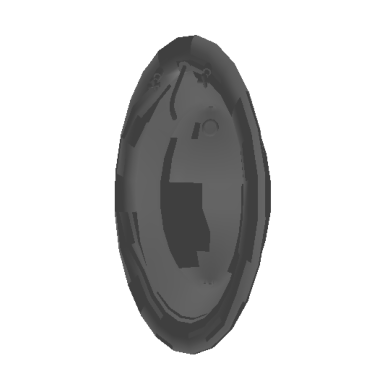

In [12]:
images = renderer(meshes, cameras=cameras, lights=lights)

# plt.figure(figsize=(10, 10))
# plt.imshow(images[0, ..., :3].cpu().numpy())
# plt.axis('off')
# plt.savefig('light_at_front.png')
# plt.show()
w, h = 1, 1
for render in range(1, w*h+1):
    plt.subplot(h, w, render)
    plt.imshow(images[2, ..., :3].cpu().numpy())
    plt.axis('off')
    plt.show()

## Меняем локацию света

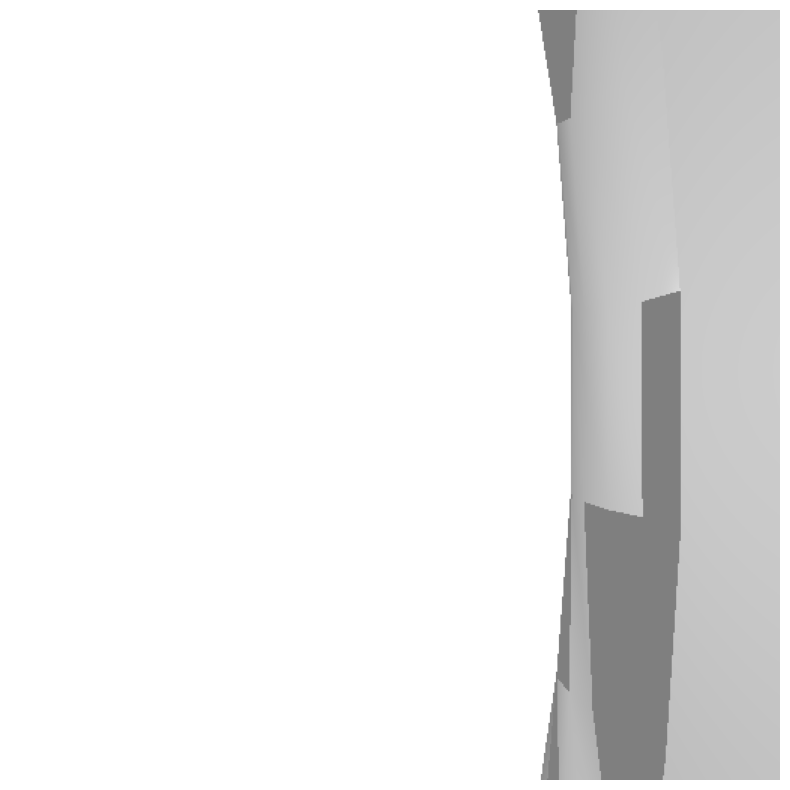

In [44]:
lights.location = torch.tensor([0.0, 0.0, +1.0], device=device).unsqueeze(0)
images = renderer(mesh)

plt.figure(figsize=(10, 10))
plt.imshow(images[0, ..., :3].cpu().numpy())
plt.axis('off')
plt.savefig('light_at_back.png')
plt.show()

## Зададим зеркальный блеск

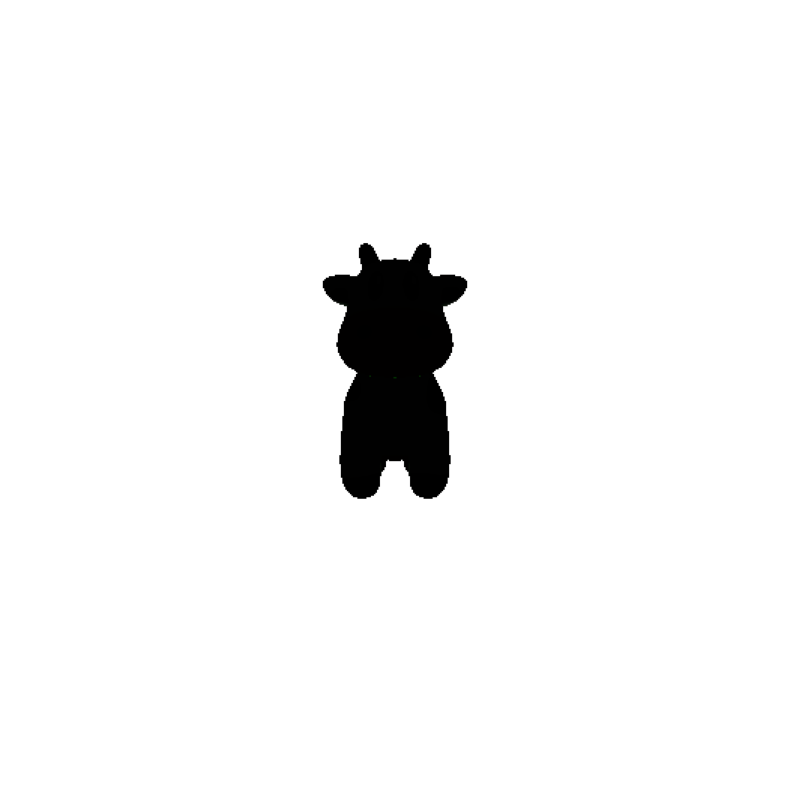

In [30]:
materials = Materials(
    device=device,
    specular_color=[[0.0, 1.0, 0.0]],
    shininess=10.0,
    ambient_color=((0.01, 0.01, 0.01), ),
)

lights.location = torch.tensor([0.0, 0.0, +1.0], device=device).unsqueeze(0)
images = renderer(mesh, light=lights, materials=materials)

plt.figure(figsize=(10, 10))
plt.imshow(images[0, ..., :3].cpu().numpy())
plt.axis('off')
plt.savefig('light_at_back_mirror.png')
plt.show()

## Повернем свет и камеру

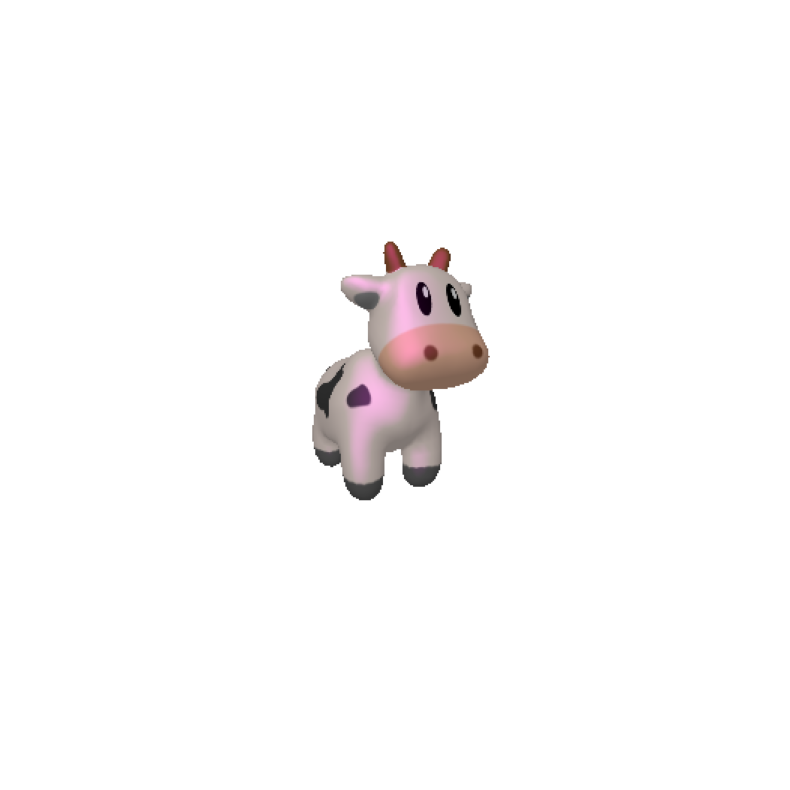

In [60]:
R, T = look_at_view_transform(dist = 2.7, elev = 10, azim = 150)
cameras = PerspectiveCameras(device=device, R=R, T=T)
lights.location = torch.tensor([[2.0, 2.0, -2.0]], device=device)

# изменить блеск с зеркального на фиолет
materials = Materials(
    device=device,
    specular_color = [[1.0, 0.0, 1.0]],
    shininess=1.0
)

# отрисовка
images = renderer(mesh, lights = lights, 
                  materials = materials, cameras=cameras)

plt.figure(figsize=(10, 10))
plt.imshow(images[0, ..., :3].cpu().numpy())
plt.axis('off')
plt.savefig('morado.png')
plt.show()